# IMPORT

In [102]:
import pandas as pd
import numpy as np
from numpy import int64
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import sys
# Lấy thư mục hiện hành của Jupyter Notebook
current_dir = os.getcwd()
# Lên 3 cấp để chỉ định thư mục gốc của dự án (chứa thư mục 'src')
project_root = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
# Thêm thư mục project_root vào sys.path để có thể Import các module từ src
if project_root not in sys.path:
    sys.path.append(project_root)
# Import data_loader (Tệp thư viện nằm tại src/services/data_loader.py)
from src.services import data_loader
from src.utils import math_engines


#LOAD DATA

In [103]:
company = 'VIC'
nlg = data_loader.load_stocks([company])
nlg = pd.DataFrame(nlg[company])
nlg.time = pd.to_datetime(nlg.time)
nlg.set_index('time', inplace=True)

Bắt đầu đọc 1 file song song...


<Axes: xlabel='time'>

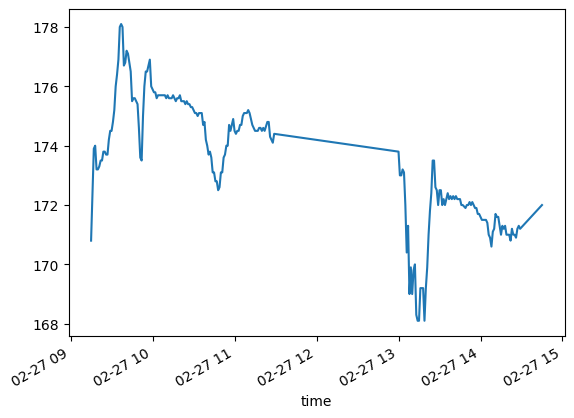

In [104]:
nlg_t = nlg[nlg.index.date == datetime(2026, 2, 27).date()]
nlg_t['close'].plot()

# TIME_BAR

<Axes: >

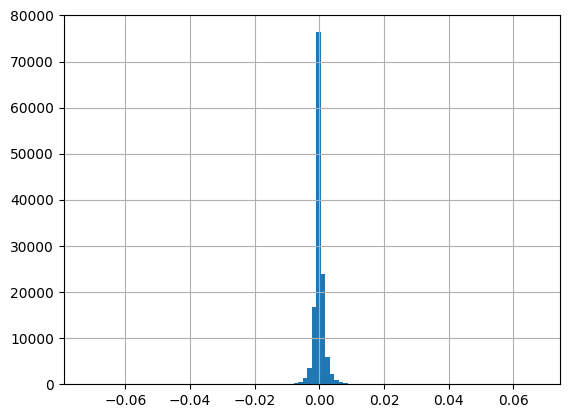

In [105]:
time_bar_return = np.log(nlg.close/nlg.close.shift(1))
time_bar_return.dropna(inplace=True)
time_bar_return.hist(bins=100)

# DOLA_BAR

## standard dola bar

In [106]:
nlg['typical_price'] = (nlg.open+nlg.high+nlg.low+nlg.close)/4
nlg['dola_value'] = nlg.typical_price*nlg.volume
# nlg.head(10)

In [107]:
def generate_dynamic_dollar_bars(df, rolling_window=20, n_target=20):
    """
    Động cơ sinh Thanh Đô la (Dollar Bars) chuẩn MLFinLab.
    - Loại bỏ Look-ahead Bias bằng Rolling Window + Shift.
    - Xử lý mượt mà dữ liệu Nến (OHLC) thay vì Tick Data thuần túy.
    """
    print("1. Bắt đầu tiền xử lý: Tính toán Bảng tra cứu Vt (Look-ahead Bias Protected)...")
    
    # Tính Tổng Đô la hàng ngày và lọc ngày nghỉ
    daily_dollar_volume = df['dola_value'].resample('D').sum()
    daily_dollar_volume = daily_dollar_volume[daily_dollar_volume > 0] 
    
    # -------------------------------------------------------------------------
    # SỬA LỖI 1: Giải quyết "Khởi động lạnh" (Cold Start Problem)
    # Thêm tham số min_periods=1 để nó tính trung bình ngay từ ngày đầu tiên có dữ liệu,
    # thay vì bắt buộc phải đợi đủ 20 ngày. Đảm bảo file test nhỏ vẫn chạy được.
    # -------------------------------------------------------------------------
    rolling_vt = (daily_dollar_volume.rolling(window=rolling_window, min_periods=1).mean() / n_target).shift(1)
    
    # -------------------------------------------------------------------------
    # SỬA LỖI 2: Đồng bộ hóa Định dạng Chìa khóa (Dictionary Hashing Fix)
    # Ép kiểu chìa khóa (k) từ pd.Timestamp về datetime.date trước khi đưa vào dict.
    # -------------------------------------------------------------------------
    vt_dict = {k.date(): v for k, v in rolling_vt.dropna().items()}

    print(f"Bảng tra cứu đã có {len(vt_dict)} ngày hợp lệ. Bắt đầu lấy mẫu...")
    
    # Khởi tạo các biến Trạng thái (State Variables)
    bars = []
    cum_dollar = 0.0
    cum_volume = 0.0
    cum_ticks = 0
    high_price = -np.inf
    low_price = np.inf
    open_price = None
    open_time = None

    # Lặp qua từng dòng dữ liệu định tuyến
    for row in df.itertuples():
        current_datetime = row.Index
        current_date = current_datetime.date()
        
        # Tra cứu Threshold một cách an toàn
        current_vt = vt_dict.get(current_date, np.nan)
        if pd.isna(current_vt):
            continue
            
        # Trích xuất dữ liệu dòng
        curr_open = row.open
        curr_high = row.high
        curr_low = row.low
        curr_close = row.close
        volume = row.volume
        dollar_val = row.dola_value
        
        # O: Giá Mở cửa là giá Open của phút ĐẦU TIÊN
        if open_price is None:
            open_price = curr_open
            open_time = current_datetime
            
        # Tích lũy Cache
        cum_dollar += dollar_val
        cum_volume += volume
        cum_ticks += 1
        
        # H & L: Chốt chặn an toàn (Safety Check) của MLFinLab
        if curr_high > high_price: high_price = curr_high
        if curr_low < low_price: low_price = curr_low
        high_price_bar = max(high_price, open_price)
        low_price_bar = min(low_price, open_price)
            
        # 4. KIỂM TRA NGƯỠNG (THRESHOLD)
        if cum_dollar >= current_vt:
            # Sinh thanh (Tương đương StandardBars._create_bars)
            bars.append({
                'open_time': open_time,
                'close_time': current_datetime, 
                'open': open_price,              
                'high': high_price_bar,              
                'low': low_price_bar,                
                'close': curr_close,             
                'volume': cum_volume,
                'dola_value': cum_dollar,        
                'tick_count': cum_ticks,
                'vt_threshold': current_vt 
            })
            
            # Reset Cache: TUYỆT ĐỐI HẤP THỤ PHẦN DƯ (Absorb Overshoot)
            # Tương đương StandardBars._reset_cache
            cum_dollar = 0.0
            cum_volume = 0.0
            cum_ticks = 0
            high_price = -np.inf
            low_price = np.inf
            open_price = None 
            open_time = None

    # Đóng gói và trả về
    dollar_bars_df = pd.DataFrame(bars)
    if not dollar_bars_df.empty:
        dollar_bars_df.set_index('close_time', inplace=True)
        
    return dollar_bars_df

In [108]:
def test_normality(bars_df, title="Dollar Bars Normality Test"):
    """
    Thực hiện kiểm định tính chuẩn toàn diện trên chuỗi Lợi suất Logarit.
    """
    # 1. Tính Log Returns
    # Thay 'close' bằng tên cột giá đóng cửa thực tế trong DataFrame của Anh
    returns = np.log(bars_df['close'] / bars_df['close'].shift(1)).dropna()
    
    # 2. Tính toán các Moment Thống kê
    skewness = stats.skew(returns)
    kurtosis = stats.kurtosis(returns) # Hàm này trả về Excess Kurtosis (Độ nhọn vượt trội so với phân phối chuẩn có mức = 0)
    
    # 3. Kiểm định Jarque-Bera
    jb_stat, p_value = stats.jarque_bera(returns)
    
    # 4. In Báo cáo
    print(f"--- BÁO CÁO THỐNG KÊ: {title} ---")
    print(f"Số lượng quan sát (N): {len(returns)}")
    print(f"Độ lệch (Skewness)  : {skewness:.4f} (Gần 0 là tốt)")
    print(f"Độ nhọn (Kurtosis)   : {kurtosis:.4f} (Gần 0 là tốt. >0 là đuôi béo)")
    print(f"Jarque-Bera Stat     : {jb_stat:.2f}")
    print(f"P-value              : {p_value:.6e}")
    
    # 5. Vẽ đồ thị Trực quan hóa
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Đồ thị Histogram & KDE so với Phân phối chuẩn
    sns.histplot(returns, kde=True, stat='density', ax=axes[0], color='blue', bins=100)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(returns), np.std(returns))
    axes[0].plot(x, p, 'k', linewidth=2, label='Normal Curve')
    axes[0].set_title('Histogram & KDE')
    axes[0].legend()
    
    # Biểu đồ Q-Q Plot
    stats.probplot(returns, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()

1. Bắt đầu tiền xử lý: Tính toán Bảng tra cứu Vt (Look-ahead Bias Protected)...
Bảng tra cứu đã có 87 ngày hợp lệ. Bắt đầu lấy mẫu...
--- BÁO CÁO THỐNG KÊ: Dollar Bars ---
Số lượng quan sát (N): 441
Độ lệch (Skewness)  : 0.2897 (Gần 0 là tốt)
Độ nhọn (Kurtosis)   : 2.6120 (Gần 0 là tốt. >0 là đuôi béo)
Jarque-Bera Stat     : 131.54
P-value              : 2.733626e-29


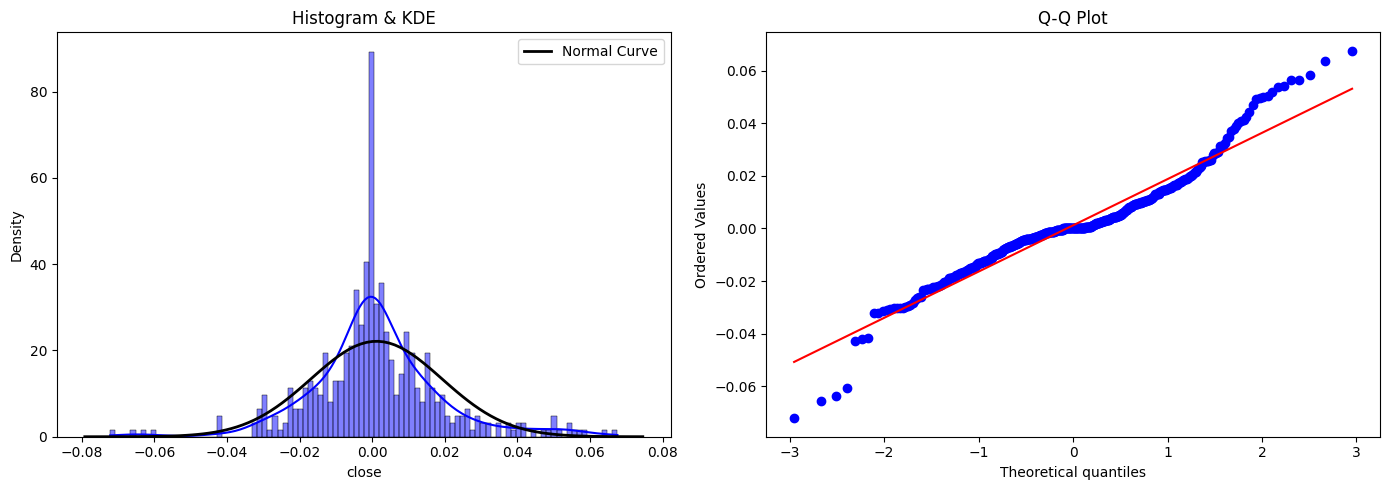

In [113]:
df = nlg[nlg.index.date >= nlg.index.date.max() - timedelta(130)]
df = generate_dynamic_dollar_bars(nlg, rolling_window=20, n_target=5)
# print(df.tail(10))
test_normality(df, "Dollar Bars")

In [110]:
def generate_time_bars_real(df, expected_bars=3078):
    """
    Động cơ sinh Thanh Thời gian (Time Bars) tương đương về tần suất.
    """
    # 1. Tính toán Tổng thời gian vật lý của chuỗi dữ liệu
    time_span = df.index[-1] - df.index[0]
    
    # 2. Tính Tần suất Lấy mẫu Trung bình (T) bằng Giây
    freq_seconds = int(time_span.total_seconds() / expected_bars)
    freq_str = f"{freq_seconds}s" # Định dạng chuẩn của Pandas (ví dụ: '300S' = 5 phút)
    
    print(f"[Time Bars] Khoảng thời gian mỗi thanh (T): {freq_seconds} giây ({freq_seconds/60:.2f} phút)")
    
    # 3. Resample theo Thời gian thực
    time_bars = df.resample(freq_str).agg(
        open=('typical_price', 'first'),
        high=('typical_price', 'max'),
        low=('typical_price', 'min'),
        close=('typical_price', 'last'),
        volume=('volume', 'sum'),
        dola_value=('dola_value', 'sum')
    )
    
    # 4. Loại bỏ các khoảng thời gian "chết" (Thị trường không có giao dịch)
    time_bars = time_bars.dropna()
    time_bars.index.name = 'close_time'
    
    print(f"[Time Bars] Số thanh thực tế tạo ra (sau khi bỏ thanh rỗng): {len(time_bars)}")
    return time_bars

[Time Bars] Khoảng thời gian mỗi thanh (T): 5625 giây (93.75 phút)
[Time Bars] Số thanh thực tế tạo ra (sau khi bỏ thanh rỗng): 397
--- BÁO CÁO THỐNG KÊ: Dollar Bars Normality Test ---
Số lượng quan sát (N): 396
Độ lệch (Skewness)  : -0.1135 (Gần 0 là tốt)
Độ nhọn (Kurtosis)   : 3.0712 (Gần 0 là tốt. >0 là đuôi béo)
Jarque-Bera Stat     : 156.48
P-value              : 1.049792e-34


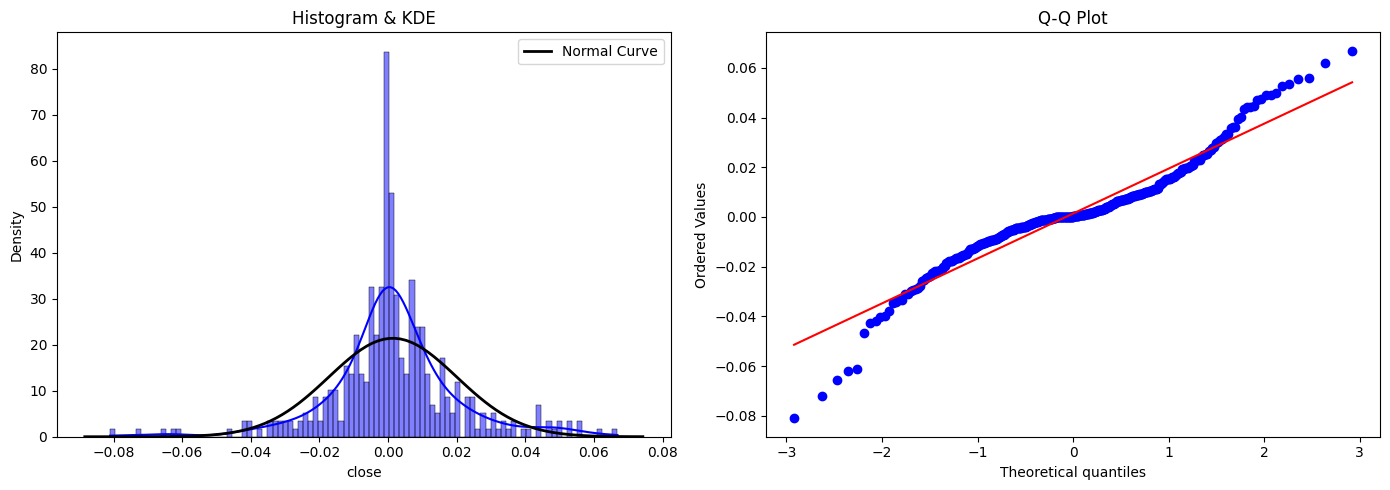

In [111]:
# Chạy thực thi
nlg = nlg[nlg.index.date >= nlg.index.date.max() - timedelta(130)]
df_time_bars = generate_time_bars_real(nlg, expected_bars=2000)
# print(df_time_bars.tail())
test_normality(df_time_bars)